# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [37]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile
import re

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.metrics import balanced_accuracy_score
from sklearn.neural_network import MLPClassifier

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
import umap.umap_ as umap


In [2]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_56621/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [3]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models

remove_columns = ["effect", "genomic position", "algorithm_pass", "Initial confidence grading",
                                              "DATASET(S)", "INITIAL CONFIDENCE GRADING", "Initial confidence grading WHO dataset", "Comment",
                                              "CHANGES vs ver1","Relaxed thresholds simulation",
                                              "Listed in abridged tables","Additional grading", "Footnote", "CHANGES vs ver1", 
                                              "(WHO guidance before cat ver1)", "Previous WHO guidance", "PPV", "Sens", "Spec", "OR"
                                                ]

pattern = '|'.join(map(re.escape, remove_columns))
master_file_clean = master_file.copy()
master_file_clean = master_file_clean.loc[:, ~master_file_clean.columns.str.contains(pattern, case=False)]


In [4]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [5]:
master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean.head())
print(master_file_clean.columns)


['4) Not assoc w R - Interim' '5) Not assoc w R'
 '3) Uncertain significance' '2) Assoc w R - Interim' '1) Assoc w R']
Index(['drug', 'gene', 'mutation', 'variant', 'tier',
       'Present_SOLO_SR_DATASET ALL', 'Present_SOLO_R_DATASET ALL',
       'Present_SOLO_S_DATASET ALL', 'Present_R_DATASET ALL',
       'Present_S_DATASET ALL', 'Absent_R_DATASET ALL', 'Absent_S_DATASET ALL',
       'k_DATASET ALL', 'Neutral_masked_DATASET ALL',
       'Present_SOLO_SR_DATASET WHO', 'Present_SOLO_R_DATASET WHO',
       'Present_SOLO_S_DATASET WHO', 'Present_R_DATASET WHO',
       'Present_S_DATASET WHO', 'Absent_R_DATASET WHO', 'Absent_S_DATASET WHO',
       'k_DATASET WHO', 'Neutral_masked_DATASET WHO', 'setA_DATASET WHO',
       'setB_DATASET WHO', 'setC_DATASET WHO', 'setD1_DATASET WHO',
       'setD2_DATASET WHO', 'v1_DATASET WHO', 'literature_DATASET WHO',
       'Present_NoPheno_no pDST', 'FINAL CONFIDENCE GRADING',
       'Silent mutation', 'grade_ordinal'],
      dtype='object')


In [6]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = master_file_clean.merge(TB_drugs, on="drug", how="left")
final_data.head()

,drug,gene,mutation,variant,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,...,setD1_DATASET WHO,setD2_DATASET WHO,v1_DATASET WHO,literature_DATASET WHO,Present_NoPheno_no pDST,FINAL CONFIDENCE GRADING,Silent mutation,grade_ordinal,smiles,fingerprint
0,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,NaN,NaN,NaN,91.0,1112.0,...,0.0,0.0,0.0,0.0,1049.0,5) Not assoc w R,Silent mutation,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Amikacin,bacA,c.-18T>C,bacA_c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Amikacin,bacA,c.-21G>A,bacA_c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Amikacin,bacA,c.-32G>A,bacA_c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,NaN,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Amikacin,bacA,c.-32G>T,bacA_c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,NaN,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
# change Nan for columns startign with Present, Sense, and Spec to -1 since they were not observed in the data, and we want to keep them for the model
for col in final_data.columns:
    if col.startswith(("Present", "Sens", "Spec")):
        final_data[col] = final_data[col].fillna(-1)

final_data["Silent mutation"] = (final_data["Silent mutation"] == "Silent mutation").astype(int)
final_data = final_data.drop(columns=["FINAL CONFIDENCE GRADING", "variant"])
final_data.head()

,drug,gene,mutation,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,...,setC_DATASET WHO,setD1_DATASET WHO,setD2_DATASET WHO,v1_DATASET WHO,literature_DATASET WHO,Present_NoPheno_no pDST,Silent mutation,grade_ordinal,smiles,fingerprint
0,Amikacin,bacA,c.1044G>A,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,...,1.0,0.0,0.0,0.0,0.0,1049.0,1,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Amikacin,bacA,c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Amikacin,bacA,c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Amikacin,bacA,c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,2459.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Amikacin,bacA,c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

one_hot_df = final_data.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- Check how many fell through to unknown ---
print(one_hot_df['mut_type'].value_counts())
unknown_mask = one_hot_df['mut_type'] == 'unknown'
print(f"\n{unknown_mask.sum()} unparsed mutations:")
for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
    print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['mut_type', 'ref', 'alt'], dummy_na=True)


print(f"num features: {len(one_hot_df.columns)}")
print(one_hot_df.columns)
one_hot_df.head()

mut_type
missense      22568
SNV            8223
frameshift     2074
del             598
nonsense        582
ins             263
delins          229
dup             225
extension        47
LoF              15
uncertain        14
Name: count, dtype: int64

0 unparsed mutations:
num features: 93
Index(['drug', 'gene', 'mutation', 'tier', 'Present_SOLO_SR_DATASET ALL',
       'Present_SOLO_R_DATASET ALL', 'Present_SOLO_S_DATASET ALL',
       'Present_R_DATASET ALL', 'Present_S_DATASET ALL',
       'Absent_R_DATASET ALL', 'Absent_S_DATASET ALL', 'k_DATASET ALL',
       'Neutral_masked_DATASET ALL', 'Present_SOLO_SR_DATASET WHO',
       'Present_SOLO_R_DATASET WHO', 'Present_SOLO_S_DATASET WHO',
       'Present_R_DATASET WHO', 'Present_S_DATASET WHO',
       'Absent_R_DATASET WHO', 'Absent_S_DATASET WHO', 'k_DATASET WHO',
       'Neutral_masked_DATASET WHO', 'setA_DATASET WHO', 'setB_DATASET WHO',
       'setC_DATASET WHO', 'setD1_DATASET WHO', 'setD2_DATASET WHO',
       'v1_DATASET WHO', 

,drug,gene,mutation,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,...,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,alt_nan
0,Amikacin,bacA,c.1044G>A,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,...,False,False,False,False,False,False,False,False,False,False
1,Amikacin,bacA,c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,False,False,False,False,False
2,Amikacin,bacA,c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,False,False,False,False,False
3,Amikacin,bacA,c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,2459.0,...,False,False,False,False,False,False,False,False,False,False
4,Amikacin,bacA,c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,True,False,False,False,False


In [9]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_copy.drop(columns=["mutation"])
one_hot_copy = pd.get_dummies(one_hot_copy, columns=["gene"])

#keep track of mapping for later
lookup_drugs = dict(enumerate(one_hot_df["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

one_hot_copy["drug"] = one_hot_copy["drug"].astype("category").cat.codes
one_hot_copy.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,drug,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,Absent_S_DATASET ALL,k_DATASET ALL,...,gene_rpsA,gene_rpsL,gene_rrl,gene_rrs,gene_sigE,gene_tlyA,gene_tsnR,gene_ubiA,gene_whiB6,gene_whiB7
0,0,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,20866.0,NaN,...,False,False,False,False,False,False,False,False,False,False
1,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,False,False,False,False,False,False,False,False,False,False
2,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,False,False,False,False,False,False,False,False,False,False
3,0,2,0.0,0.0,0.0,1.0,0.0,2459.0,21978.0,1832.0,...,False,False,False,False,False,False,False,False,False,False
4,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(one_hot_copy["fingerprint"].tolist(), index=one_hot_copy.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([one_hot_copy.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
print(final_ml.shape)
final_ml.head()

(34838, 2202)


,drug,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,Absent_S_DATASET ALL,k_DATASET ALL,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,0,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,20866.0,NaN,...,0,0,0,0,0,0,0,0,0,0
1,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,0,0,0,0,0,0,0,0,0,0
3,0,2,0.0,0.0,0.0,1.0,0.0,2459.0,21978.0,1832.0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,1832.0,...,0,0,0,0,0,0,0,0,0,0


##### NOW WE CAN START TESTING MODELS #####

In [11]:
# first remove any columns with inf values, then fill any remaining nan values with the median of each column
final_ml.replace([np.inf, -np.inf], np.nan, inplace=True) # replace
final_ml = final_ml.fillna(-1)

# let's run a random train test split first
X_baseline = final_ml.drop(columns=["grade_ordinal", "drug"])
y_baseline = final_ml["grade_ordinal"]

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline)


# scale the data
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

# convert back to dataframe
XS_train = pd.DataFrame(XS_train, columns=X_baseline.columns)
XS_test = pd.DataFrame(XS_test, columns=X_baseline.columns)

# Run a logistic regression model as a baseline
baseline_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model.fit(XS_train, y_train)
y_pred_baseline = baseline_model.predict(XS_test)
print("Classification Report for Baseline Logistic Regression:")
print(classification_report(y_test, y_pred_baseline))

Classification Report for Baseline Logistic Regression:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        94
         2.0       1.00      0.97      0.98      6601
         3.0       0.52      0.93      0.67       224
         4.0       0.71      0.84      0.77        49

    accuracy                           0.97      6968
   macro avg       0.81      0.93      0.85      6968
weighted avg       0.98      0.97      0.97      6968



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


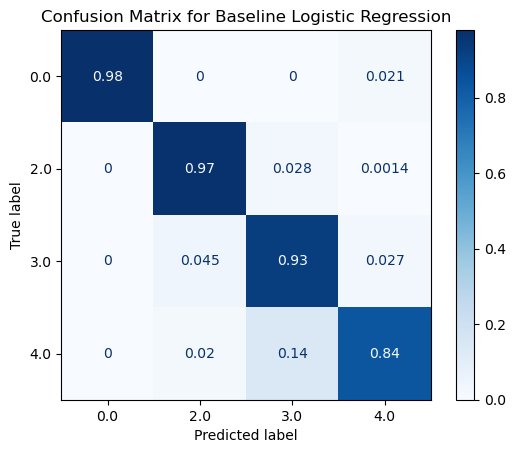

In [12]:
# plot the confusion matrix for the baseline model
cm = confusion_matrix(y_test, y_pred_baseline, labels=baseline_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Baseline Logistic Regression")
plt.show()

In [13]:
# check the balanced accuracy
balanced_accuracy_baseline_random = balanced_accuracy_score(y_test, y_pred_baseline)
print(balanced_accuracy_baseline_random)

0.9286600100657125


In [14]:
## Holdout 'Amikacin' and 'Kanamycin' because they are both aminoglycosides
holdout_drugs_two = ['Amikacin', 'Kanamycin']
holdout_codes = [code for code, drug in lookup_drugs.items() if drug in holdout_drugs_two]
print(f"Holdout drug codes: {holdout_codes}")

stress_test_two_drugs = final_ml.copy()
stress_test_two_drugs.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan
stress_test_two_drugs = stress_test_two_drugs.fillna(-1) # fill any nan values

train_holdout2 = stress_test_two_drugs[~stress_test_two_drugs["drug"].isin(holdout_codes)].copy()
test_holdout2 = stress_test_two_drugs[stress_test_two_drugs["drug"].isin(holdout_codes)].copy()

X_train_holdout2 = train_holdout2.drop(columns=["grade_ordinal", "drug"])
y_train_holdout2 = train_holdout2["grade_ordinal"]
X_test_holdout2 = test_holdout2.drop(columns=["grade_ordinal", "drug"])
y_test_holdout2 = test_holdout2["grade_ordinal"]

print(f"Training set shape: {X_train_holdout2.shape}")
print(f"Holdout set shape: {X_test_holdout2.shape}")

Holdout drug codes: [0, 8]
Training set shape: (31159, 2200)
Holdout set shape: (3679, 2200)


In [15]:
# first remove any columns with inf values, then fill any remaining nan values with the median of each column
# scale the data
scaler = StandardScaler()
XS_train_holdout2 = scaler.fit_transform(X_train_holdout2)
XS_test_holdout2 = scaler.transform(X_test_holdout2)

# convert back to dataframe
XS_train_holdout2 = pd.DataFrame(XS_train_holdout2, columns=X_train_holdout2.columns)
XS_test_holdout2 = pd.DataFrame(XS_test_holdout2, columns=X_train_holdout2.columns)

# Run a logistic regression model as a baseline
baseline_model_holdout2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_holdout2.fit(XS_train_holdout2, y_train_holdout2)
y_pred_baseline_holdout2 = baseline_model_holdout2.predict(XS_test_holdout2)
print("Classification Report for Baseline Logistic Regression Removing 2 drugs:")
print(classification_report(y_test_holdout2, y_pred_baseline_holdout2))

Classification Report for Baseline Logistic Regression Removing 2 drugs:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        83
         2.0       1.00      1.00      1.00      3585
         3.0       0.00      0.00      0.00         4
         4.0       1.00      0.71      0.83         7

    accuracy                           1.00      3679
   macro avg       0.75      0.68      0.71      3679
weighted avg       1.00      1.00      1.00      3679



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/metri

0.6785714285714286


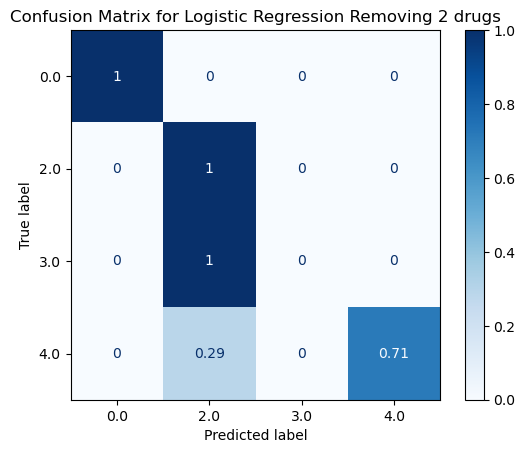

In [16]:
# check the balanced accuracy
balanced_accuracy_holdout2 = balanced_accuracy_score(y_test_holdout2, y_pred_baseline_holdout2)
print(balanced_accuracy_holdout2)

# plot the confusion matrix for the baseline model
cm_holdout = confusion_matrix(y_test_holdout2, y_pred_baseline_holdout2, labels=baseline_model_holdout2.classes_, normalize='true')
disp_holdout = ConfusionMatrixDisplay(confusion_matrix=cm_holdout, display_labels=baseline_model_holdout2.classes_)
disp_holdout.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Removing 2 drugs")
plt.show()

### Next we will look at how reducing dimensionality might improve our accuracy scores

In [17]:
## First we know that the morgan fingerprints add the highest number of features
# let's run PCA on just the morgan fingerprints 

# copy the dataset first
X_train_fp = X_train_holdout2
y_train_fp = y_train_holdout2
X_test_fp = X_test_holdout2
y_test_fp = y_test_holdout2

# now let's remove the fingerprint columns
fp_columns = [c for c in X_train_holdout2 if c.startswith('fp_')]

# let's separate the fingerprints so we can run PCA 
X_train_fp_only = X_train_fp[fp_columns]
X_test_fp_only = X_test_fp[fp_columns]
# remaining columns like mutation data
X_train_remaining = X_train_fp.drop(columns=fp_columns)
X_test_remaining = X_test_fp.drop(columns=fp_columns)

print(f"FP shape: {X_train_fp_only.shape}")
print(f"Remaining data shape: {X_train_remaining.shape}")

FP shape: (31159, 2048)
Remaining data shape: (31159, 152)


In [18]:
# Run PCA only on the fingerprints 

# scale the data
scaler_fp = StandardScaler()

X_fp_train_scaled = scaler_fp.fit_transform(X_train_fp_only)
X_fp_test_scaled = scaler_fp.transform(X_test_fp_only)

pca = PCA(n_components=0.95, random_state=42)

# run PCA
X_fp_train_PCA = pca.fit_transform(X_fp_train_scaled)
X_fp_test_PCA = pca.transform(X_fp_test_scaled)

# convert to DF
X_fp_train_PCA = pd.DataFrame(X_fp_train_PCA, index=X_train_fp_only.index)
X_fp_test_PCA = pd.DataFrame(X_fp_test_PCA, index=X_test_fp_only.index)

In [19]:
# add the PCA columns back for hte full data readout
X_train_final_pca = pd.concat([X_train_remaining, X_fp_train_PCA], axis=1)
X_test_final_pca = pd.concat([X_test_remaining, X_fp_test_PCA], axis=1)

# convert column names to strings
X_train_final_pca.columns = [f"fp_pca_{i}" for i in range(X_train_final_pca.shape[1])]
X_test_final_pca.columns = [f"fp_pca_{i}" for i in range(X_test_final_pca.shape[1])]

# scale the full data again
scaler_full = StandardScaler()
X_train_final_pca_scaled = scaler_full.fit_transform(X_train_final_pca)
X_test_final_pca_scaled = scaler_full.transform(X_test_final_pca)

In [20]:
# Run a logistic regression model with CPA
baseline_model_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_pca.fit(X_train_final_pca_scaled, y_train_fp)
y_pred_pca = baseline_model_pca.predict(X_test_final_pca_scaled)
print("Classification Report for Logistic Regression with PCA")
print(classification_report(y_test_fp, y_pred_pca))

Classification Report for Logistic Regression with PCA
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        83
         2.0       1.00      0.98      0.99      3585
         3.0       0.02      0.25      0.03         4
         4.0       1.00      0.71      0.83         7

    accuracy                           0.98      3679
   macro avg       0.75      0.74      0.71      3679
weighted avg       1.00      0.98      0.99      3679



0.7367478581390716


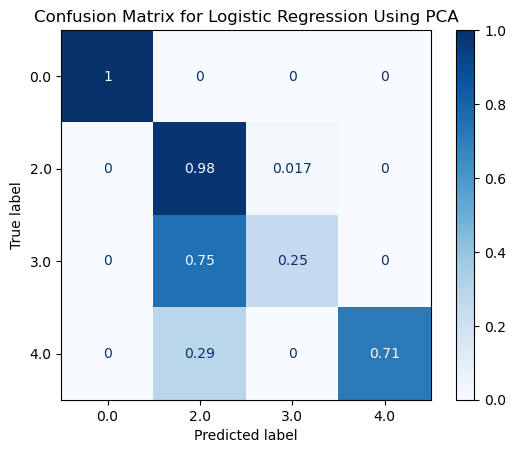

In [21]:
# check the balanced accuracy
balanced_accuracy_pca = balanced_accuracy_score(y_test_fp, y_pred_pca)
print(balanced_accuracy_pca)

# plot the confusion matrix for the baseline model
cm_pca = confusion_matrix(y_test_fp, y_pred_pca, labels=baseline_model_pca.classes_, normalize='true')
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=baseline_model_pca.classes_)
disp_pca.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using PCA")
plt.show()

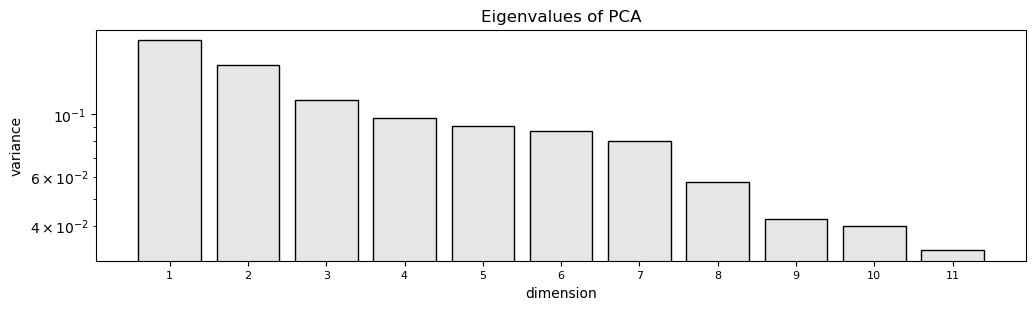

In [24]:
eigenVec = pca.components_
eigenVal = pca.explained_variance_ratio_
xplot = np.arange(1, 12)

fig = plt.figure(figsize=(12, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('variance')
plt.yscale('log')
plt.xticks(xplot, size=8)
plt.title('Eigenvalues of PCA')
plt.show()

In [25]:
# finally let's just run with elastic net
# Fit a logistic regression model using elastic net, balance the data for each class

# copy the dataset first
X_train_regularization = X_train_holdout2.copy()
y_train_regularization = y_train_holdout2.copy()
X_test_regularization = X_test_holdout2.copy()
y_test_regularization = y_test_holdout2.copy()

# scale
scaler_enet = StandardScaler()

X_train_enet = scaler_enet.fit_transform(X_train_regularization)
X_test_enet = scaler_enet.transform(X_test_regularization)

# train model
enet_model = LogisticRegression(max_iter=1000, solver='saga', l1_ratio=0.1,
                                class_weight='balanced', C=0.1, random_state=42)
enet_model.fit(X_train_enet, y_train_regularization)

#predict 
y_pred_enet = enet_model.predict(X_test_enet)

print("Classification Report for Logistic Regression with Elastic Net")
print(classification_report(y_test_regularization, y_pred_enet))

Classification Report for Logistic Regression with Elastic Net
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        83
         2.0       1.00      0.98      0.99      3585
         3.0       0.00      0.00      0.00         4
         4.0       0.83      0.71      0.77         7

    accuracy                           0.98      3679
   macro avg       0.71      0.67      0.69      3679
weighted avg       1.00      0.98      0.99      3679



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.674178123132098


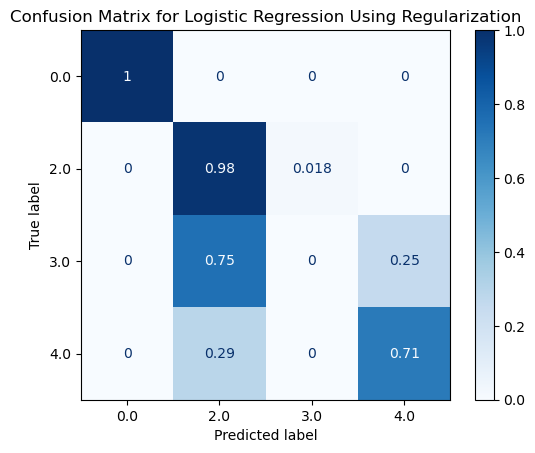

In [27]:
# check the balanced accuracy
balanced_accuracy_regularization = balanced_accuracy_score(y_test_regularization, y_pred_enet)
print(balanced_accuracy_regularization)

# plot the confusion matrix for the baseline model
cm_enet = confusion_matrix(y_test_regularization, y_pred_enet, labels=enet_model.classes_, normalize='true')
disp_enet = ConfusionMatrixDisplay(confusion_matrix=cm_enet, display_labels=enet_model.classes_)
disp_enet.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using Regularization")
plt.show()

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99        83
         2.0       1.00      0.96      0.98      3585
         3.0       0.00      0.00      0.00         4
         4.0       0.62      0.71      0.67         7

    accuracy                           0.96      3679
   macro avg       0.65      0.67      0.66      3679
weighted avg       1.00      0.96      0.98      3679

Balanced Accuracy: 0.67
Epochs run: 45
Best validation score: 0.9922978177150192


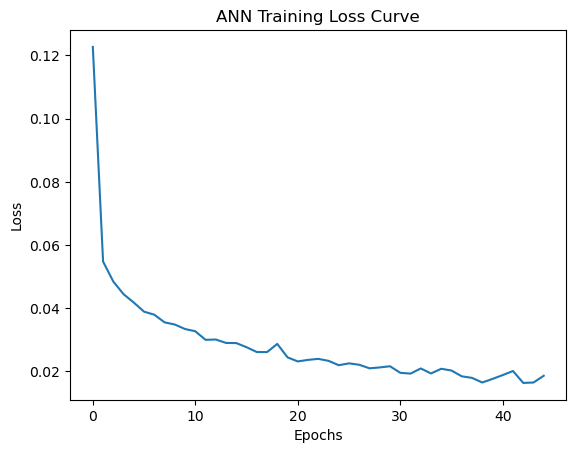

In [28]:
# test using a ANN
# set up ANN
X_train_ANN = X_train_holdout2.copy()
y_train_ANN = y_train_holdout2.copy()
X_test_ANN = X_test_holdout2.copy()
y_test_ANN = y_test_holdout2.copy()

# scale
scaler_ann = StandardScaler()
XS_train_ann = scaler_ann.fit_transform(X_train_ANN)
XS_test_ann = scaler_ann.transform(X_test_ANN)

ann_model = MLPClassifier(hidden_layer_sizes=(64,32),
                                  activation="relu",
                                  alpha=0.001,
                                  max_iter=500,
                                  random_state=42,
                                  early_stopping=True,
                                  validation_fraction=0.1)

ann_model.fit(XS_train_ann, y_train_ANN)
y_pred_ann = ann_model.predict(XS_test_ann)
print(classification_report(y_test_ANN, y_pred_ann))

# Display the accuracy
accuracy_ann = balanced_accuracy_score(y_test_ANN, y_pred_ann)
print(f'Balanced Accuracy: {accuracy_ann:.2f}')

print(f"Epochs run:", ann_model.n_iter_)
print(f"Best validation score: {ann_model.best_validation_score_}")

plt.plot(ann_model.loss_curve_)
plt.title("ANN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


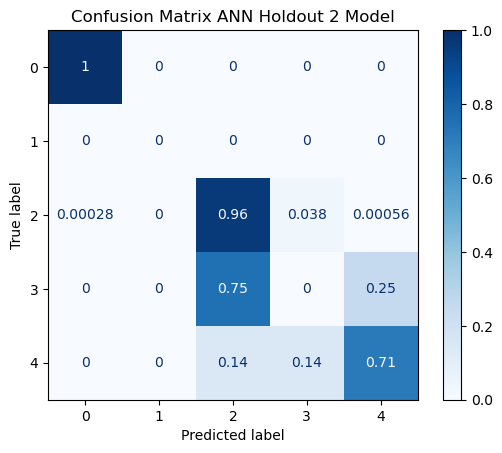

In [29]:
# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm_ann = confusion_matrix(y_test_ANN, y_pred_ann, normalize = 'true', labels=labels)
disp_ANN = ConfusionMatrixDisplay(confusion_matrix = cm_ann)
disp_ANN.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix ANN Holdout 2 Model")
plt.show()

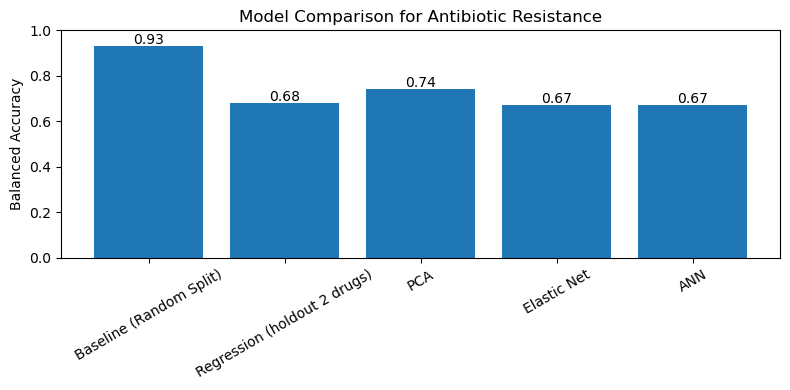

In [36]:
## now let's plot the accuracies for all the models

models = [
    "Baseline (Random Split)",
    "Regression (holdout 2 drugs)",
    "PCA",
    "Elastic Net",
    "ANN"
]

balanced_accuracies = [
    0.93,
    0.68,
    0.74,
    0.67,
    0.67
]

plt.figure(figsize=(8,4))

bars = plt.bar(models, balanced_accuracies)

plt.ylabel("Balanced Accuracy")
plt.title("Model Comparison for Antibiotic Resistance")
plt.ylim(0,1)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha="center")
    
plt.tight_layout()
plt.show()